Análise dos tipos de colisões e ocorrências mais frequentes no trânsito, permitindo identificar os principais padrões de acidentes na região.

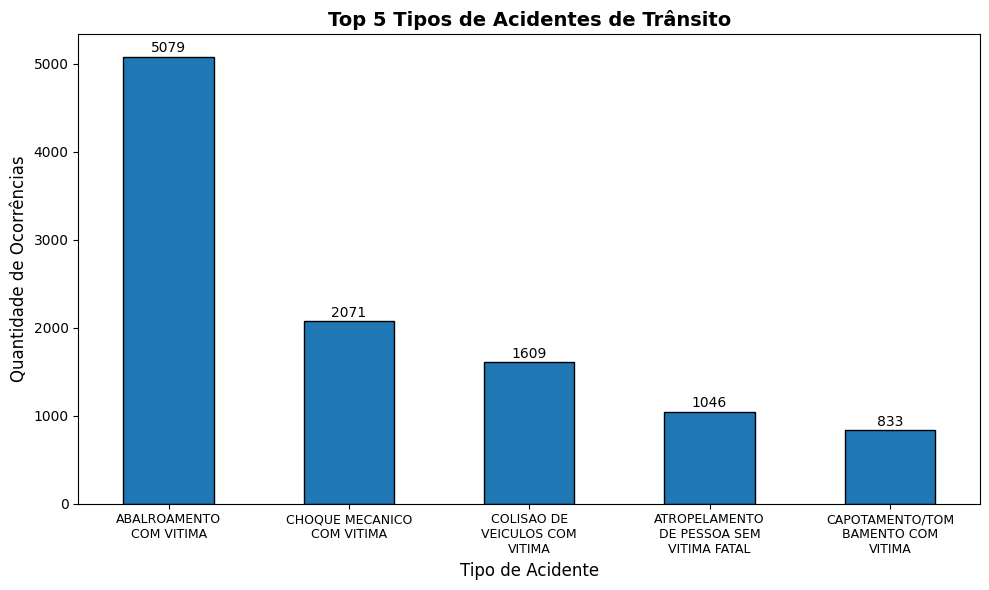

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap # <-- Importação nativa do Python para quebrar textos

# 1 e 2. Carrega os dados e pega os 5 maiores (igual você já fez)
df = pd.read_csv("dados/acidentes_transito_limpo.csv")
top_5_acidentes = df['DESC_TIPO_ACIDENTE'].value_counts().head(5)

# Pega os nomes originais e cria uma nova lista quebrando a linha a cada 15 caracteres
nomes_originais = top_5_acidentes.index.tolist()
nomes_quebrados = [textwrap.fill(nome, width=15) for nome in nomes_originais]

# 3. Configura o visual do gráfico
plt.figure(figsize=(10, 6))
grafico = top_5_acidentes.plot(kind='bar', color='#1f77b4', edgecolor='black')

# 4. Adiciona títulos e rótulos

plt.title('Top 5 Tipos de Acidentes de Trânsito', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Acidente', fontsize=12)
plt.ylabel('Quantidade de Ocorrências', fontsize=12)

# 5. Aplica os nomes com quebra de linha e mantém o texto reto (rotation=0)
# Ajustamos os "ticks" para colocar as novas labels alinhadas ao centro
plt.xticks(ticks=range(len(nomes_quebrados)), labels=nomes_quebrados, rotation=0, ha='center', fontsize=9)

# 6. Adiciona o número exato em cima de cada barra
for index, value in enumerate(top_5_acidentes):
    plt.text(index, value + 50, str(value), ha='center', fontsize=10)

# 7. Ajusta o layout e exibe o gráfico
plt.tight_layout()
plt.show()

Através desta análise em linha temporal, podemos observar o comportamento dos acidentes mês a mês. O objetivo é identificar possíveis picos sazonais (como feriados ou meses de chuva) que demandem maior atenção das autoridades de trânsito.

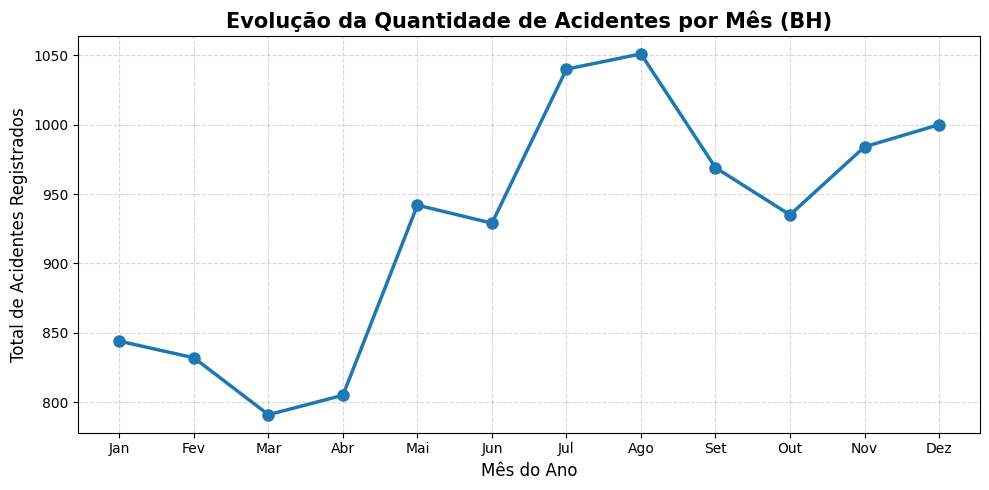

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carrega os dados limpos
df_acidentes = pd.read_csv("dados/acidentes_transito_limpo.csv")

# 2. Transforma a coluna de texto em uma Data real (Datetime) para o Python entender
df_acidentes['DATA_REAL'] = pd.to_datetime(df_acidentes['DATA HORA_BOLETIM'], format='%d/%m/%Y %H:%M')

# 3. Extrai apenas o número do mês (1 a 12)
df_acidentes['Mes_Num'] = df_acidentes['DATA_REAL'].dt.month

# 4. Conta os acidentes por mês e organiza do mês 1 ao 12
acidentes_por_mes = df_acidentes['Mes_Num'].value_counts().sort_index()

meses_siglas = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun', 
                7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}

# 5. Cria o DataFrame
df_plot = pd.DataFrame({
    'Mes': acidentes_por_mes.index.map(meses_siglas), # O nosso eixo X
    'Quantidade': acidentes_por_mes.values            # O nosso eixo Y
})

# 6. PLOTANDO O GRÁFICO DE LINHA
plt.figure(figsize=(10, 5))

# Cor, espessura e tamanho da bolinha
plt.plot('Mes', 'Quantidade', data=df_plot, linestyle='-', marker='o', 
         color='#1f77b4', linewidth=2.5, markersize=8)

# 7. Títulos
plt.title('Evolução da Quantidade de Acidentes por Mês (BH)', fontsize=15, fontweight='bold')
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Total de Acidentes Registrados', fontsize=12)

# Adiciona grade no fundo
plt.grid(True, linestyle='--', alpha=0.5)

# 8. Ajusta e exibe
plt.tight_layout()
plt.show()

Embora o volume total de acidentes seja alto, é fundamental isolar a métrica de letalidade. Este gráfico destaca a proporção exata de acidentes que, infelizmente, resultaram em perda de vidas, evidenciando a gravidade das ocorrências.

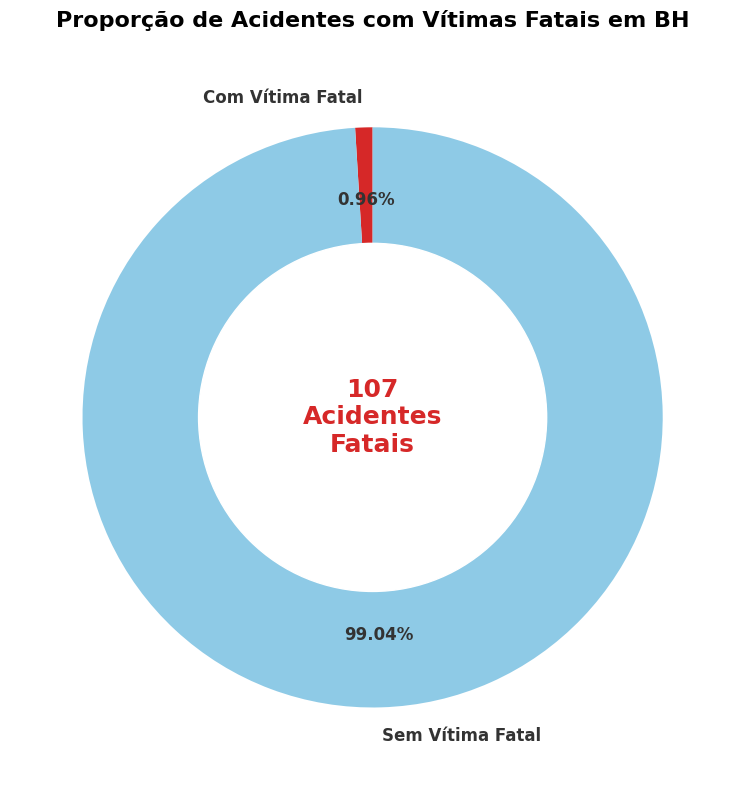

Total de Acidentes: 11122
Acidentes Fatais: 107
Acidentes Sem Vítima Fatal: 11015


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carrega a base de dados limpa
df_acidentes = pd.read_csv("dados/acidentes_transito_limpo.csv")

# 2. Calcula os números de acidentes fatais e não fatais
total_acidentes = len(df_acidentes)
acidentes_fatais = len(df_acidentes[df_acidentes['INDICADOR_FATALIDADE'] == 'SIM'])
acidentes_nao_fatais = total_acidentes - acidentes_fatais

# 3. Prepara as fatias, rótulos e cores
tamanhos = [acidentes_fatais, acidentes_nao_fatais]
rotulos = ['Com Vítima Fatal', 'Sem Vítima Fatal']
cores = ['#d62828', '#8ecae6'] 

# 4. Cria o Gráfico de Pizza base com a porcentagem
plt.figure(figsize=(8, 8))
plt.pie(
    tamanhos, 
    labels=rotulos,       # Adiciona o nome de cada fatia do lado de fora
    colors=cores, 
    startangle=90,        # Inicia a fatia vermelha no topo
    autopct='%1.2f%%',    # Adiciona a porcentagem com 2 casas decimais
    pctdistance=0.75,     # Ajusta a posição da porcentagem para ficar na parte colorida
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#333333'}
)

# 5. Adiciona o círculo branco no centro para fazer o Donut Chart
circulo_centro = plt.Circle((0,0), 0.60, color='white') #define a espessura da rosca
fig = plt.gcf()
fig.gca().add_artist(circulo_centro)

# 6. Adiciona um texto de destaque no centro
plt.text(0, 0, f"{acidentes_fatais}\nAcidentes\nFatais", 
         ha='center', va='center', fontsize=18, fontweight='bold', color='#d62828')

# 7. Finaliza e exibe
plt.title('Proporção de Acidentes com Vítimas Fatais em BH', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Imprime os valores reais no terminal para contexto
print(f"Total de Acidentes: {total_acidentes}")
print(f"Acidentes Fatais: {acidentes_fatais}")
print(f"Acidentes Sem Vítima Fatal: {acidentes_nao_fatais}")

A análise de dados nunca ocorre no vácuo. Este visual revela que as 107 fatalidades de trânsito representaram uma porcentagem estatisticamente pequena em relação às mortes totais daquele ano. No entanto, é crucial contextualizar esse percentual: 2021 foi um ano severamente impactado pela pandemia de COVID-19, o que inflou atipicamente o número de óbitos por outras causas na região.

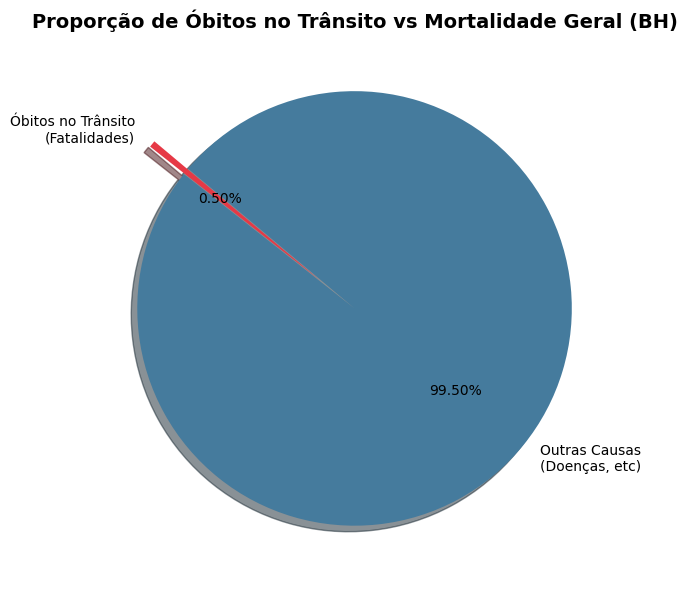

Total de Óbitos Gerais: 21607
Total de Óbitos no Trânsito: 107


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar as duas bases de dados limpas
df_obitos = pd.read_csv("dados/obitos_gerais_bh_2021.csv")
df_acidentes = pd.read_csv("dados/acidentes_transito_limpo.csv")

# 2. Calcular os números exatos
# Soma a coluna inteira de óbitos gerais
total_obitos_gerais = df_obitos['Total_Obitos_Gerais'].sum() 

# Filtra os acidentes onde houve fatalidade e conta quantas linhas sobraram
total_obitos_transito = len(df_acidentes[df_acidentes['INDICADOR_FATALIDADE'] == 'SIM']) 

# Calcula as mortes por outras causas para fechar 100% da pizza
obitos_outras_causas = total_obitos_gerais - total_obitos_transito

# 3. Preparar os dados para o gráfico
fatias = [total_obitos_transito, obitos_outras_causas]
nomes = ['Óbitos no Trânsito\n(Fatalidades)', 'Outras Causas\n(Doenças, etc)']
cores = ['#e63946', '#457b9d'] # Vermelho para trânsito (alerta), Azul para outras
destaque = (0.2, 0) # "Puxa" a fatia do trânsito um pouco para fora para dar destaque

# 4. Criar e configurar o gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(
    fatias, 
    labels=nomes, 
    colors=cores, 
    explode=destaque, 
    autopct='%1.2f%%', # Formata a porcentagem com 2 casas decimais
    startangle=140,    # Gira a pizza para uma posição mais estética
    shadow=True        # Adiciona um sombreamento 3D
)

# 5. Título e exibição
plt.title('Proporção de Óbitos no Trânsito vs Mortalidade Geral (BH)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Imprime os números reais abaixo do gráfico para contexto
print(f"Total de Óbitos Gerais: {total_obitos_gerais}")
print(f"Total de Óbitos no Trânsito: {total_obitos_transito}")

Para evitar distorções causadas pelo tamanho da cidade, cruzamos os dados de trânsito com a população total estimada. Esta métrica (taxa a cada 100 mil habitantes) é o padrão internacional para medir o risco real a que os cidadãos estão expostos diariamente nas vias.

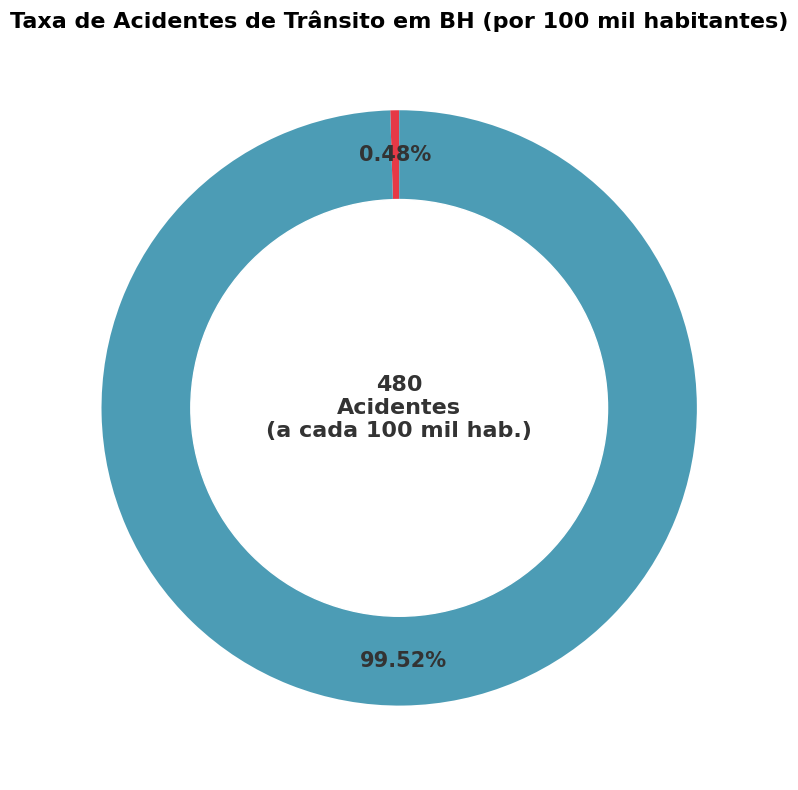

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carrega os dados e define a população
df_acidentes = pd.read_csv("dados/acidentes_transito_limpo.csv")
total_acidentes = len(df_acidentes) 
populacao_bh = 2315560              

# 2. Calcula a proporção (Taxa por 100 mil habitantes)
taxa_acidentes_100k = (total_acidentes / populacao_bh) * 100000
resto_populacao = 100000 - taxa_acidentes_100k

# 3. Prepara as fatias e cores
tamanhos = [taxa_acidentes_100k, resto_populacao]
cores = ['#e63946', "#4c9cb5"] 

# 4. Porcentagem
plt.figure(figsize=(8, 8))
plt.pie(
    tamanhos, 
    colors=cores, 
    startangle=90,
    autopct='%1.2f%%',    # Calcula e exibe a porcentagem com 2 casas decimais
    pctdistance=0.85,     # Empurra a porcentagem para a borda colorida (fora do buraco)
    textprops={'fontsize': 15, 'fontweight': 'bold', 'color': '#333333'} # Estilo do texto
)

# 5. Adiciona o círculo branco no centro para fazer o Donut
circulo_centro = plt.Circle((0,0), 0.70, color='white') 
fig = plt.gcf()
fig.gca().add_artist(circulo_centro)

# 6. Adiciona o texto no centro
plt.text(0, 0, f"{int(taxa_acidentes_100k)}\nAcidentes\n(a cada 100 mil hab.)", 
         ha='center', va='center', fontsize=16, fontweight='bold', color='#333333')

# 7. Finaliza e exibe
plt.title('Taxa de Acidentes de Trânsito em BH (por 100 mil habitantes)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()